In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.stats import wilcoxon, ttest_rel
import os

In [4]:
import matplotlib.font_manager as fm
# ============================================================
# Fonts / style
# ============================================================
font_paths = [
    "/home/gzu5140/Font/Arial.ttf",
    "/home/gzu5140/Font/Arial Bold.ttf",
    "/home/gzu5140/Font/Arial Italic.ttf",
    "/home/gzu5140/Font/Arial Bold Italic.ttf",
]

for fp in font_paths:
    try:
        fm.fontManager.addfont(fp)
        print("✔ Loaded font:", fp)
    except Exception as e:
        print("⚠️  Could not load:", fp, "|", e)

# ==== LaTeX + SVG text mode (Illustrator-safe) ====
import matplotlib.pyplot as plt
plt.rcParams['pdf.fonttype'] = 42  # For PDF export
plt.rcParams['ps.fonttype'] = 42   # For PostScript (EPS) export
plt.rcParams['font.sans-serif'] = ["Arial"]
plt.rcParams['font.family'] = "sans-serif"
plt.rcParams['svg.fonttype'] = "none"
plt.rcParams['mathtext.fontset'] = "cm"
plt.rcParams['axes.labelsize'] = 18     # x/y labels
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['xtick.labelsize'] = 12     # x-axis tick labels
plt.rcParams['ytick.labelsize'] = 12    # y-axis tick labels
plt.rcParams['legend.fontsize'] = 12    # legend text

✔ Loaded font: /home/gzu5140/Font/Arial.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Italic.ttf
✔ Loaded font: /home/gzu5140/Font/Arial Bold Italic.ttf


## Code for plots in Figure 4

In [5]:
#Path to the plot data
path_to_plot_data = "/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_data/New_additive/"
#/home/gzu5140/Keerthana_b1042/grnInference/plot_data/figure_4_data/New_additive//twins_random_zscore_summary.csv
path_to_plots = "/home/gzu5140/Keerthana_b1042/grnInference/plots/figure_4/"
os.makedirs(path_to_plots, exist_ok = True)

## Panel 2d

In [4]:
gene_gene_corr_data_path = f"{path_to_plot_data}/gene_gene_matrix_results.csv"
gene_gene_corr_data = pd.read_csv(gene_gene_corr_data_path)

In [5]:
gene_pair = "g1_g2"

In [8]:
sim_types_to_plot = ['Fan_out','Feed_forward', 'Mutual_regulation']
labels_plot = ["Fan-out", "Feed-forward loop", "Regulated mutual"]
colors = ['#bc2462', '#754c29', '#006838', '#ee8d39']

# Collect all iteration values for g1_g2 (equivalent to iloc[0,1])
all_values = []
all_thresholds = []

for sim_type in sim_types_to_plot:
    # Filter data for this simulation type
    sim_data = gene_gene_corr_data[gene_gene_corr_data['sim_type'] == sim_type]
    
    # Get g1_g2 values (change column name if different)
    vals = sim_data[gene_pair].values.tolist()  # or whatever your gene pair column is
    thresholds = sim_data['threshold'].values.tolist()
    
    all_values.append(vals)
    all_thresholds.append(thresholds)

# Flatten thresholds for min/max calculation
flat_thresholds = [item for sublist in all_thresholds for item in sublist]

# --- Main boxplot for gene_gene values ---
fig, ax = plt.subplots(figsize=(6, 4))

# REMOVE ALL BACKGROUNDS
ax.set_facecolor('none')         # Axes background transparent
plt.ylabel(r"gene correlation $\rho$")

# Add mean threshold line
ax.axhline(np.mean(flat_thresholds), 
          linestyle="--", 
          color="black", 
          linewidth=1, 
          alpha=0.7,
          label="Mean threshold")

# Create boxplot
box = ax.boxplot(all_values, labels=labels_plot, patch_artist=True, showfliers=True)

# Style each component with matching color
# Change this line:
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor('none')
    patch.set_edgecolor(color)  # Use set_color() instead of set_edgecolor()
    patch.set_linewidth(0.5)

for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box['medians'], colors):
    median.set_color(color)
    median.set_linewidth(0.5)

for flier, color in zip(box['fliers'], colors):
    flier.set_markerfacecolor(color)
    flier.set_markeredgecolor(color)
    flier.set_markersize(4)

# DISABLE CLIPPING for all elements (prevents masks in Illustrator)
for element_list in [box['boxes'], box['whiskers'], box['caps'], box['medians']]:
    for element in element_list:
        element.set_clip_on(False)

plt.savefig(f'{path_to_plots}/gene_gene_correlation_{gene_pair}.png', 
           format='png', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f'{path_to_plots}/gene_gene_correlation_{gene_pair}.svg', 
           format='svg', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f'{path_to_plots}/gene_gene_correlation_{gene_pair}.pdf', 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency

plt.show()

NameError: name 'gene_gene_corr_data' is not defined

## Panel 2e

/tmp/ipykernel_3332203/1352569935.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot,
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


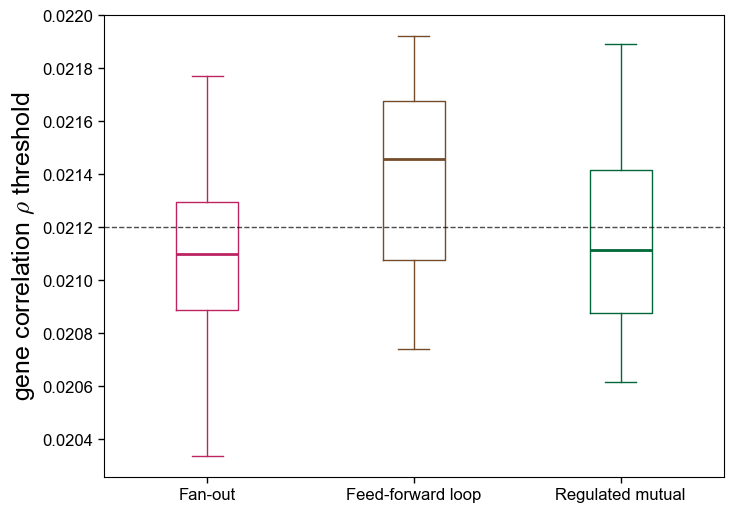

In [10]:
# Create standalone threshold plot
fig_threshold, ax_threshold = plt.subplots(figsize=(8, 6))

# Create threshold boxplot
box_threshold = ax_threshold.boxplot(all_thresholds, labels=labels_plot, 
                                   patch_artist=False, showfliers=True)
ax_threshold.axhline(np.mean(flat_thresholds), linestyle="--", color="black", linewidth=1, alpha=0.7)

# Style threshold boxplot with matching colors
for patch, color in zip(box_threshold['boxes'], colors):
    patch.set_color(color)

for whisker, color in zip(box_threshold['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)

for cap, color in zip(box_threshold['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

for median, color in zip(box_threshold['medians'], colors):
    median.set_color(color)
    median.set_linewidth(2)

# Style outliers
for flier, color in zip(box_threshold['fliers'], colors):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor(color)
        flier.set_markeredgecolor(color)
        flier.set_markersize(4)

# DISABLE CLIPPING
for element_list in [box_threshold['boxes'], box_threshold['whiskers'], box_threshold['caps'], box_threshold['medians']]:
    for element in element_list:
        element.set_clip_on(False)

# Style axes
ax_threshold.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    # labelbottom=False, labelleft=False,
    length=4, width=1
)
plt.ylabel(r"gene correlation $\rho$ threshold")
# Save threshold plot
plt.savefig(f'{path_to_plots}/gene_gene_correlation_threshold_boxplot.svg', 
           format='svg', 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)
plt.savefig(f'{path_to_plots}/gene_gene_correlation_threshold_boxplot.pdf', 
           format='pdf', 
           bbox_inches='tight',
           facecolor='none',
           edgecolor='none',
           transparent=True)

plt.show()

## Panel 2f and 2g

In [10]:
# Load the data
random_correlation_path = f"{path_to_plot_data}/random_matrix_results.csv"
twin_correlation_t1_path= f"{path_to_plot_data}/twin_t1_matrix_results.csv"
random_correlation_data = pd.read_csv(random_correlation_path)
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)

In [6]:
import pandas as pd

# Load data about twin correlation, z-scores and median of random pair correlations
loaded_df = pd.read_csv(f"{path_to_plot_data}/twins_random_zscore_summary_fin.csv")

# Helper function: extract list for a specific network + metric
def extract_list(df, net, metric, gene_pair_set):
    return df[(df.network_type == net) & (df.metric == metric) & (df.gene_pair == gene_pair_set)]["values"].tolist()

# === Reconstruct all 9 lists ===

Fan_out_medians  = extract_list(loaded_df, "Fan_out", "medians", "('gene_2', 'gene_3')")
Fan_out_z_scores = extract_list(loaded_df, "Fan_out", "z_scores", "('gene_2', 'gene_3')")
Fan_out_threshold = extract_list(loaded_df, "Fan_out", "z_threshold_list_neg", "('gene_2', 'gene_3')")

Feed_forward_medians = extract_list(loaded_df, "Feed_forward", "medians", "('gene_2', 'gene_3')")
Feed_forward_z_scores = extract_list(loaded_df, "Feed_forward", "z_scores","('gene_2', 'gene_3')")
Feed_forward_threshold = extract_list(loaded_df, "Feed_forward", "z_threshold_list_neg", "('gene_2', 'gene_3')")

Mutual_regulation_medians = extract_list(loaded_df, "Mutual_regulation", "medians", "('gene_2', 'gene_3')")
Mutual_regulation_z_scores = extract_list(loaded_df, "Mutual_regulation", "z_scores", "('gene_2', 'gene_3')")
Mutual_regulation_threshold = extract_list(loaded_df, "Mutual_regulation", "z_threshold_list_neg", "('gene_2', 'gene_3')")


In [12]:
gene_pair = "g2_g3"

In [13]:
# random-pair correlation medians
random_correlation_medians = [
    Fan_out_medians,
    Feed_forward_medians,
    Mutual_regulation_medians,
]
threshold_lists = [
    Fan_out_threshold,
    Feed_forward_threshold,
    Mutual_regulation_threshold
]
colors = ['#194a9e', '#006937', '#ee9127']
light_colors = ['#194a9e', '#006937', '#ee9127']
# Collect data for plotting
all_data = []
all_colors = []
positions = []
thresholds_1pct = []
z_scores = []
z_scores = [Fan_out_z_scores, Feed_forward_z_scores, Mutual_regulation_z_scores]
pos = 1
for i, sim_type in enumerate(sim_types_to_plot):
    
    # 1. Use random correlation medians
    random_vals = np.array(random_correlation_medians[i])
    random_vals = random_vals[~np.isnan(random_vals)]
    
    # 2. Get twin correlation data from CSV
    twin_sim = twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == sim_type]
    twin_vals = twin_sim[gene_pair].values  # Adjust column name if needed
    
    if len(random_vals) > 0 and len(twin_vals) > 0:
        # Calculate 1st percentile threshold from random medians        
        # Add to plotting data (random medians first, then twin)
        all_data.extend([random_vals, twin_vals])
        all_colors.extend([light_colors[i], colors[i]])
        positions.extend([pos, pos + 1])       
        pos += 3  # Space between groups
    else:
        print(f"Warning: {sim_type} missing data - Random: {len(random_vals)}, Twin: {len(twin_vals)}")


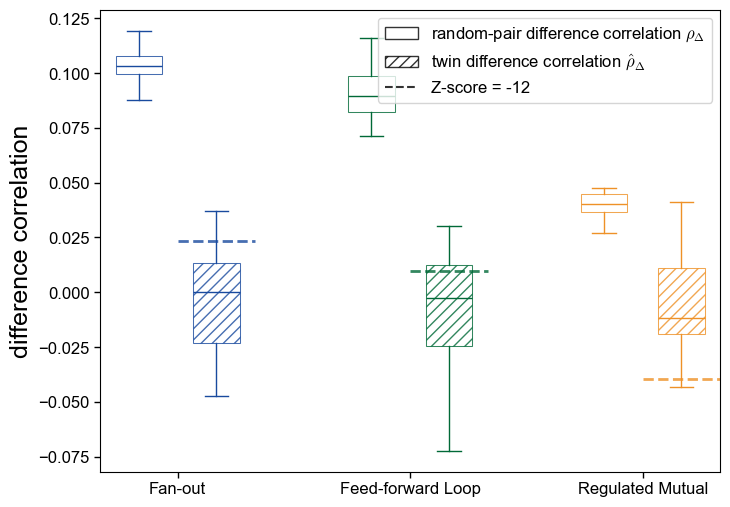

In [16]:
# Define simulation types and colors 
sim_types_to_plot = ['Fan_out', 'Feed_forward', 'Mutual_regulation']
colors = ['#194a9e', '#006937', '#ee9127']

if len(all_data) > 0:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # REMOVE ALL BACKGROUNDS
    fig.patch.set_facecolor('none')  # Figure background transparent
    ax.set_facecolor('none')         # Axes background transparent

    # Create boxplot with different styles
    box = ax.boxplot(all_data, positions=positions, patch_artist=True, showfliers=True, widths=0.6)
    
    for i, (median_line, color) in enumerate(zip(box['medians'], all_colors)):
        median_line.set_color(color)
        median_line.set_visible(True)
    
    # Color and style the boxes differently for random vs twin
    for i, (patch, color) in enumerate(zip(box['boxes'], all_colors)):
        if i % 2 == 0:  # Random boxes (even indices)
            patch.set_facecolor('none')
            patch.set_edgecolor(color)
            patch.set_linewidth(0.75)
            patch.set_alpha(0.8)
        else:  # Twin boxes (odd indices)
            patch.set_facecolor("none")
            patch.set_edgecolor(color)  # Black outline
            patch.set_linewidth(0.75)
            hatch = '///'  # Define the hatch pattern
            patch.set_hatch(hatch)  # Hatching for twin boxes
            patch.set_linestyle('-')   # Solid outline for twin
            patch.set_alpha(0.8)
        # DISABLE CLIPPING for Illustrator compatibility
        patch.set_clip_on(False)

    # Style whiskers, caps, and medians differently
    for i, whisker in enumerate(box['whiskers']):
        whisker.set_color(all_colors[i//2])
        whisker.set_linewidth(1)
        whisker.set_clip_on(False)
        if (i // 2) % 2 == 0:  # Random whiskers
            whisker.set_linestyle('-')
        else:  # Twin whiskers
            whisker.set_linestyle('-')

    for i, cap in enumerate(box['caps']):
        cap.set_color(all_colors[i//2])
        cap.set_linewidth(1)
        cap.set_clip_on(False)
        if (i // 2) % 2 == 0:  # Random caps
            cap.set_linestyle('-')
        else:  # Twin caps
            cap.set_linestyle('-')

    for i, flier in enumerate(box['fliers']):
        if len(flier.get_data()[0]) > 0:
            print(i)
            flier.set_markerfacecolor('none')
            flier.set_markeredgecolor(all_colors[i])
            flier.set_markersize(4)

    # Add z-score = -10 threshold lines for each group
    z_score_threshold = -12
    group_x_ranges = [(0.5, 2.5), (3.5, 5.5), (6.5, 8.5)]  # x-ranges for each group
    for i, (x_start, x_end) in enumerate(group_x_ranges):
        mean_threshold = np.median(threshold_lists[i])

        ax.hlines(
            mean_threshold,
            x_start + 1,
            x_end,
            colors=colors[i],
            linestyles='--',
            linewidth=2,
            alpha=0.8
        )
        # ax.hlines(z_10_threshold, x_start+1, x_end, 
        #              colors=colors[i], linestyles='--', linewidth=2, alpha=0.8)
    # z_score_threshold = 10
    # group_x_ranges = [(0.5, 2.5), (3.5, 5.5), (6.5, 8.5)]  # x-ranges for each group
    # for i, (x_start, x_end) in enumerate(group_x_ranges):
    #     # Calculate where z-score = -10 would be for each group
    #     random_mean = np.mean(all_data[i*2])  # Random medians for this group
    #     random_std = np.std(all_data[i*2])
    #     z_10_threshold = random_mean + (z_score_threshold * random_std)
        
    #     ax.hlines(z_10_threshold, x_start+1, x_end, 
    #                  colors=colors[i], linestyles='--', linewidth=2, alpha=0.8)

    # Set x-axis labels
    group_centers = [1.5, 4.5, 7.5]  # Centers of each pair
    ax.set_xticks(group_centers)
    ax.set_xticklabels(["Fan-out", "Feed-forward Loop", "Regulated Mutual"])

    # Add legend with different styles
    legend_elements = [
        Patch(facecolor='none', edgecolor='black', linestyle='-',
              alpha=0.8, label = r"random-pair difference correlation $\rho_\Delta$"),
        Patch(facecolor='none', edgecolor='black', linestyle='-',
              alpha=0.8, hatch='///', label = r"twin difference correlation $\hat{\rho}_\Delta$"),
        Line2D([0], [0], color='black', linestyle='--', alpha=0.8, label = "Z-score = -12")
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    # Clean styling for Illustrator
    ax.set_ylabel('difference correlation')
    ax.set_title('')
    
    ax.tick_params(
            axis='both',
            which='both',
            bottom=True, top=False, left=True, right=False,
            # labelbottom=False, labelleft=False,
            length=4, width=1
        )

    # Save with Illustrator-friendly settings
    # plt.savefig(f"{path_to_plots}/twin_correlation_{gene_pair}.svg", 
    #            format="svg", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    # plt.savefig(f"{path_to_plots}/twin_correlation_{gene_pair}.png", 
    #            format="png", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    # plt.savefig(f"{path_to_plots}/twin_correlation_{gene_pair}.pdf", 
    #            format="pdf", 
    #            bbox_inches='tight',
    #            facecolor='none',      # Transparent figure background
    #            edgecolor='none',      # No edge color
    #            transparent=True)      # Ensure transparency
    
    plt.show()
else:
    print("No valid data available for plotting!")


In [17]:
threshold_lists = [
    Fan_out_threshold,
    Feed_forward_threshold,
    Mutual_regulation_threshold
]

for i, sim_type in enumerate(sim_types_to_plot):
    twin_vals = np.array(all_data[i * 2 + 1])      # twin correlations
    thresh_vals = np.array(threshold_lists[i])    # thresholds

    n = min(len(twin_vals), len(thresh_vals))
    count = np.sum(twin_vals[:n] < thresh_vals[:n])

    print(
        f"{sim_type}: {count} / {n} "
        f"({count / n:.2%}) twin correlations < threshold"
    )


Fan_out: 19 / 20 (95.00%) twin correlations < threshold
Feed_forward: 14 / 20 (70.00%) twin correlations < threshold
Mutual_regulation: 1 / 20 (5.00%) twin correlations < threshold


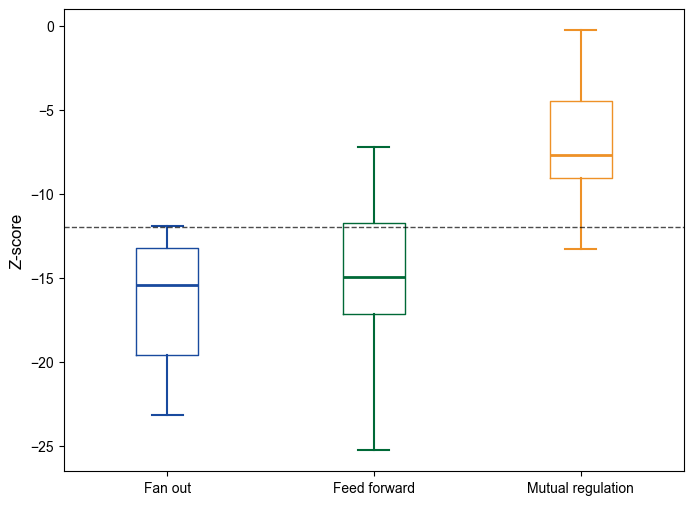

In [15]:
fig_zscore = plt.figure(figsize=(8, 6))
ax_zscore = fig_zscore.add_subplot(111)

# Create z-score boxplot using the z_scores calculated above
z_box = ax_zscore.boxplot(z_scores, patch_artist=False, showfliers=True)

# Style z-score boxplot with matching colors
for i, patch in enumerate(z_box['boxes']):
    patch.set_color(colors[i])
    patch.set_clip_on(False)

for i, median in enumerate(z_box['medians']):
    median.set_color(colors[i])
    median.set_linewidth(2)
    median.set_clip_on(False)

for i, whisker in enumerate(z_box['whiskers']):
    whisker.set_color(colors[i//2])
    whisker.set_linewidth(1.5)
    whisker.set_clip_on(False)

for i, cap in enumerate(z_box['caps']):
    cap.set_color(colors[i//2])
    cap.set_linewidth(1.5)
    cap.set_clip_on(False)

# Style outliers
for i, flier in enumerate(z_box['fliers']):
    if len(flier.get_data()[0]) > 0:
        flier.set_markerfacecolor("none")
        flier.set_markeredgecolor(colors[i])
        flier.set_markersize(4)

# Add z-score thresholds
#ax_zscore.axhline(-1*z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7, label="z-score threshold")
ax_zscore.axhline(z_score_threshold, linestyle="--", color="black", linewidth=1, alpha=0.7)


# Set labels and styling
ax_zscore.set_xticks([1,2,3])
ax_zscore.set_xticklabels(["Fan out", "Feed forward", "Mutual regulation"])
ax_zscore.set_ylabel("Z-score", fontsize=12)
ax_zscore.tick_params(labelsize=10)
# ax_zscore.legend(fontsize=10)

# Save z-score plot
# plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.pdf", 
#            format="pdf", 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)
# plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.svg", 
#            format="svg", 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)
# plt.savefig(f"{path_to_plots}/zscore_boxplot_{gene_pair}.png", 
#            format="png", 
#            bbox_inches='tight',
#            facecolor='none',
#            edgecolor='none',
#            transparent=True)

plt.show()

## Panel 2h

In [30]:
twin_correlation_t1_path = f"{path_to_plot_data}/twin_t1_matrix_results.csv"
twin_correlation_t1_data = pd.read_csv(twin_correlation_t1_path)
twin_correlation_t2_path = f"{path_to_plot_data}/twin_t2_matrix_results.csv"
twin_correlation_t2_data = pd.read_csv(twin_correlation_t2_path)

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

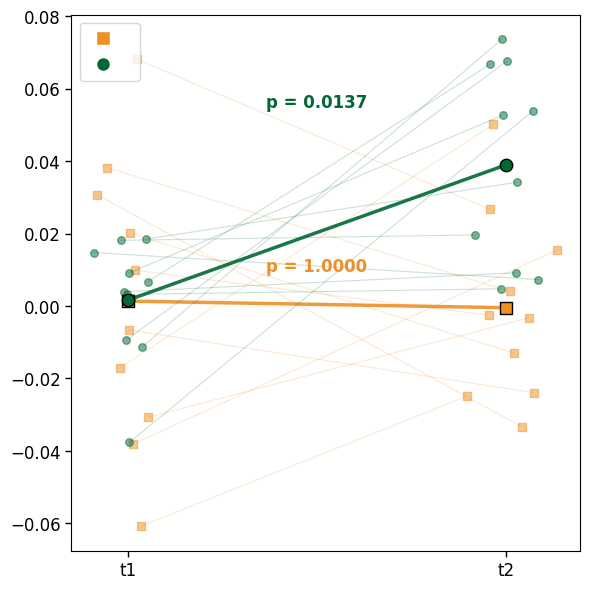

In [34]:
sim_types_to_plot = ['A_B_2_states', 'A_to_B_2_states']
colors = ['#ed9126', '#006935']
markers = ["s", "o"]
fig, ax = plt.subplots(figsize=(6, 6))

# REMOVE ALL BACKGROUNDS
#figure_2_v3_2x_cells  # Figure background transparent
ax.set_facecolor('none')         # Axes background transparent

x_positions = {'t1': 0.2, 't2': 0.8}  # shift away from the edges
mean_points = {}
differences = []

# Store legend handles
legend_handles = []

for i, (sim_type, color, marker) in enumerate(zip(sim_types_to_plot, colors, markers)):
    # Get data from CSV files
    t1_sim_data = twin_correlation_t1_data[twin_correlation_t1_data['sim_type'] == sim_type]
    t2_sim_data = twin_correlation_t2_data[twin_correlation_t2_data['sim_type'] == sim_type]
    
    t1_vals = (t1_sim_data['g2_g1'].values)[:10]  # Adjust column name if needed
    t2_vals = (t2_sim_data['g2_g1'].values)[:10]  # Adjust column name if needed
    differences = list(t2_vals - t1_vals) 
    mean = np.mean(differences)
    std_dev = np.std(differences)
    # --- Perform Wilcoxon signed-rank test ---
    stat, p_value = wilcoxon(t1_vals, t2_vals)
    
    # Format p-value
    p_text = f"p = {p_value:.4f}"

    # --- Jittered strip plot ---
    jitter_t1 = np.random.normal(x_positions['t1'], 0.03, size=len(t1_vals))
    jitter_t2 = np.random.normal(x_positions['t2'], 0.03, size=len(t2_vals))

    scatter1 = ax.scatter(jitter_t1, t1_vals, color=color, alpha=0.5, s=30, marker = marker)
    scatter2 = ax.scatter(jitter_t2, t2_vals, color=color, alpha=0.5, s=30, marker = marker)
    
    # DISABLE CLIPPING for scatter plots
    scatter1.set_clip_on(False)
    scatter2.set_clip_on(False)

    # --- Light individual connection lines ---
    for x1, y1, x2, y2 in zip(jitter_t1, t1_vals, jitter_t2, t2_vals):
        line = ax.plot([x1, x2], [y1, y2], color=color, alpha=0.2, linewidth=0.8)[0]
        line.set_clip_on(False)

    # --- Mean connection ---
    mean_t1, mean_t2 = np.mean(t1_vals), np.mean(t2_vals)
    mean_points[sim_type] = (mean_t1, mean_t2)

    mean_line = ax.plot(
        [x_positions['t1'], x_positions['t2']],
        [mean_t1, mean_t2],
        color=color,
        linewidth=2.5,
        alpha=0.9
    )[0]

    mean_line.set_clip_on(False)
    
    mean_scatter = ax.scatter(
        [x_positions['t1'], x_positions['t2']],
        [mean_t1, mean_t2],
        color=color,
        s=80,
        edgecolor='black',
        zorder=3,
        marker = marker,
        # label=f"{sim_type} mean"
    )
    mean_scatter.set_clip_on(False)
    
    # Store legend handle (using the mean scatter plot for cleaner legend)
    legend_handles.append(plt.Line2D([0], [0], marker=marker, color='w', 
                                   markerfacecolor=color, markersize=10, 
                                   linewidth=0))
    
    # --- Add p-value text above the mean line ---
    # Position text above the higher of the two mean points
    text_y = max(mean_t1, mean_t2) + (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.05 * (i + 1)
    text_x = np.mean([x_positions['t1'], x_positions['t2']])
    
    ax.text(text_x, text_y, p_text, 
           color=color, 
           fontsize=12, 
           fontweight='bold',
           ha='center', 
           va='bottom')

# Add legend with no text labels
ax.legend(legend_handles, ['', ''], loc='upper left', frameon=True)

# --- Aesthetics ---
ax.set_xticks([x_positions['t1'], x_positions['t2']])
ax.set_xticklabels(['t1', 't2'])
ax.set_ylabel("")
# ax.set_title("t1 = 1h, t2= 20h, Wilcoxon test")
# ax.grid(True, axis='y', alpha=0.3)

# Style tick parameters for clean look
ax.tick_params(
    axis='both',
    which='both',
    bottom=True, top=False, left=True, right=False,
    labelbottom=True, labelleft=True,  # Hides tick labels
    length=4, width=1
)
ax.grid(False)  # Remove grid lines for final version

plt.tight_layout()

# Save with Illustrator-friendly settings
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.png", 
           format="png",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.svg", 
           format="svg",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.savefig(f"{path_to_plots}/change_in_twin_correlation.svg", 
           format="svg",
           bbox_inches='tight',
           facecolor='none',      # Transparent figure background
           edgecolor='none',      # No edge color
           transparent=True)      # Ensure transparency
plt.show()